# BUCSS 2026
## AI Session Hands-On Part 1: Data Insights and Pre-processing

In this notebook you will:
- Load observational data from weather station networks of different cities
- Visualize observations
- Prepare data sets for training (next part, different notebook)

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cmcrameri.cm as cmc

#These are internal
from scripts.dataprep import load_data
from scripts.plotting import obs_map, week_plot, quick_raster_plot

First, let's decide which city you want to extract your data from:

In [29]:
city = "bern"
data = load_data(city) #options are "bern", "dortmund", "freiburg", "ghent"

# print(data) #you can check out how we load the data in ../scripts/dataprep.py 
# this returns a basic dataframe with a station id, coordinates, datetime of the measurement and the
# measured value in °C
 


loading pre-existing dataframe


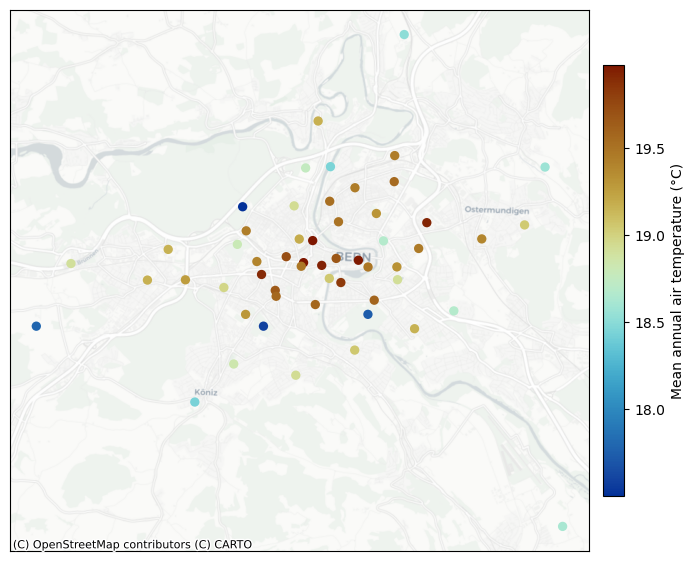

(<Figure size 900x800 with 2 Axes>, <Axes: >)

In [30]:
# We can do a basic map to display where the measurements took place, with circles colored by their average temperature

# we take the mean observed temperature for each station and in so doing collapse the datafame
# to one row per station
stn = (data.groupby("station_id")
            .agg(longitude=("longitude", "first"),
                    latitude=("latitude", "first"),
                    tmean=("air_temperature", "mean"))
            .reset_index())

obs_map(stn, value_col = "tmean")

Let's see how a typical diurnal cycle would look for the hottest and coldest stations, in the hottest week of summer.

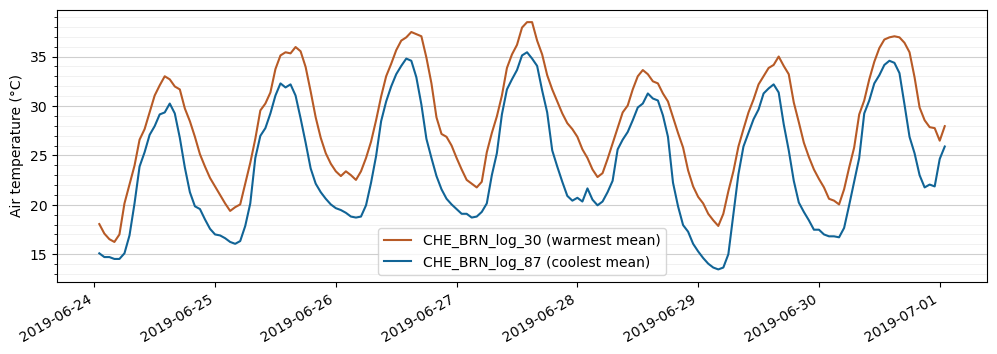

(<Figure size 1200x400 with 1 Axes>, <Axes: ylabel='Air temperature (°C)'>)

In [31]:
# find the time with the absolute hottest temperature measured
hottest_time = data.loc[data["air_temperature"].idxmax(), "datetime_utc"]

# we set up a time window that is a week long, centered around the hottest time
half = pd.Timedelta(days=3.5)
lo, hi = hottest_time - half, hottest_time + half
window = data["datetime_utc"].between(lo, hi)

# filter to stations that have data during this hot week
in_window = data[window]

# observation count per station within the window
counts = in_window.groupby("station_id")["datetime_utc"].count()

# keep stations with >= 70% of the best-covered station's count
threshold = 0.5 * counts.max()
present_ids = counts[counts >= threshold].index

# mean temp per WELL-COVERED station during the window
stn = (in_window[in_window["station_id"].isin(present_ids)]
           .groupby("station_id")["air_temperature"].mean()
           .rename("tmean").reset_index())

hot_id  = stn.loc[stn["tmean"].idxmax(), "station_id"]
cold_id = stn.loc[stn["tmean"].idxmin(), "station_id"]

hot_week  = data[(data["station_id"] == hot_id)  & window].sort_values("datetime_utc")
cold_week = data[(data["station_id"] == cold_id) & window].sort_values("datetime_utc")

week_plot(hot_week, cold_week, hot_id, cold_id)

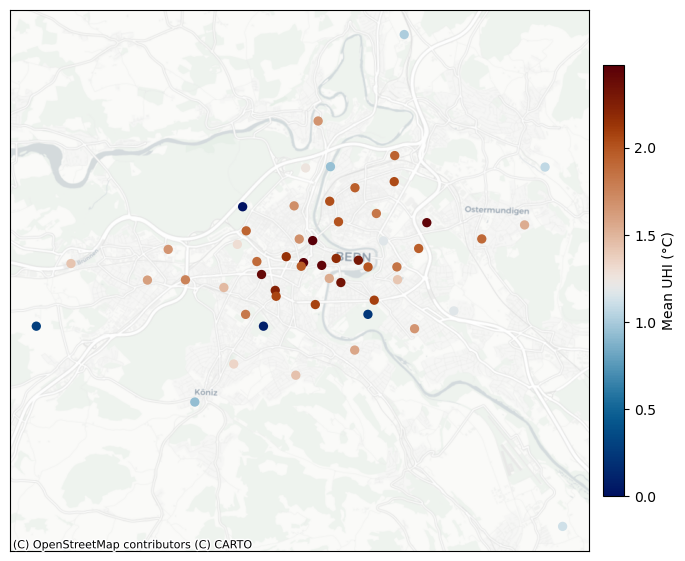

(<Figure size 900x800 with 2 Axes>, <Axes: >)

In [32]:

stn = (data.groupby("station_id")
            .agg(longitude=("longitude", "first"),
                    latitude=("latitude", "first"),
                    tmean=("air_temperature", "mean"))
            .reset_index())

rural_id = stn.loc[stn["tmean"].idxmin(), "station_id"]


rural = (data.loc[data["station_id"] == rural_id, ["datetime_utc", "air_temperature"]]
             .rename(columns={"air_temperature": "t_rural"}))

m = data.merge(rural, on="datetime_utc", how="inner")

m["uhi"] = m["air_temperature"] - m["t_rural"]

uhi = m.groupby("station_id")["uhi"].mean().reset_index(name="uhi_mean")

uhi = uhi.merge(stn[["station_id", "longitude", "latitude"]], on="station_id")

obs_map(uhi, value_col = "uhi_mean")

Why are the Bern values so high ? Let's take a closer look at what time period they cover:

In [33]:
print(data["datetime_utc"].min())
print(data["datetime_utc"].max())

2019-05-14 22:00:00+00:00
2022-09-15 21:00:00+00:00


Maybe that's not enough, let's make a histogram that displays the number of observations per month:

/scratch/local/11817810/ipykernel_1612661/4036120785.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  months = data["datetime_utc"].dt.to_period("M")


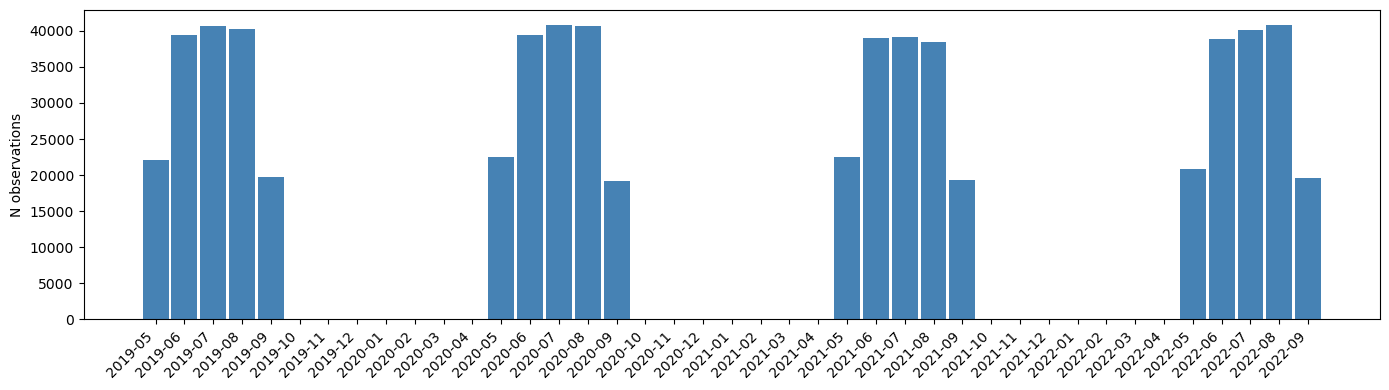

(<Figure size 1400x400 with 1 Axes>, <Axes: ylabel='N observations'>)

In [34]:
def obs_per_month(data: pd.DataFrame):
    #group the data per month
    months = data["datetime_utc"].dt.to_period("M")

    # count observations per calendar month
    counts = months.value_counts().sort_index()

    # build the FULL month range and reindex -> missing months become 0
    full = pd.period_range(counts.index.min(), counts.index.max(), freq="M")
    counts = counts.reindex(full, fill_value=0)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(counts.index.astype(str), counts.values, width=0.9, color="steelblue")
    ax.set_ylabel("N observations")

    # thin the x labels so they don't collide
    step = max(1, len(counts) // 24)
    ax.set_xticks(range(0, len(counts), step))
    ax.set_xticklabels([str(counts.index[i]) for i in range(0, len(counts), step)],
                       rotation=45, ha="right")
    fig.tight_layout()
    plt.show()
    return fig, ax

obs_per_month(data)

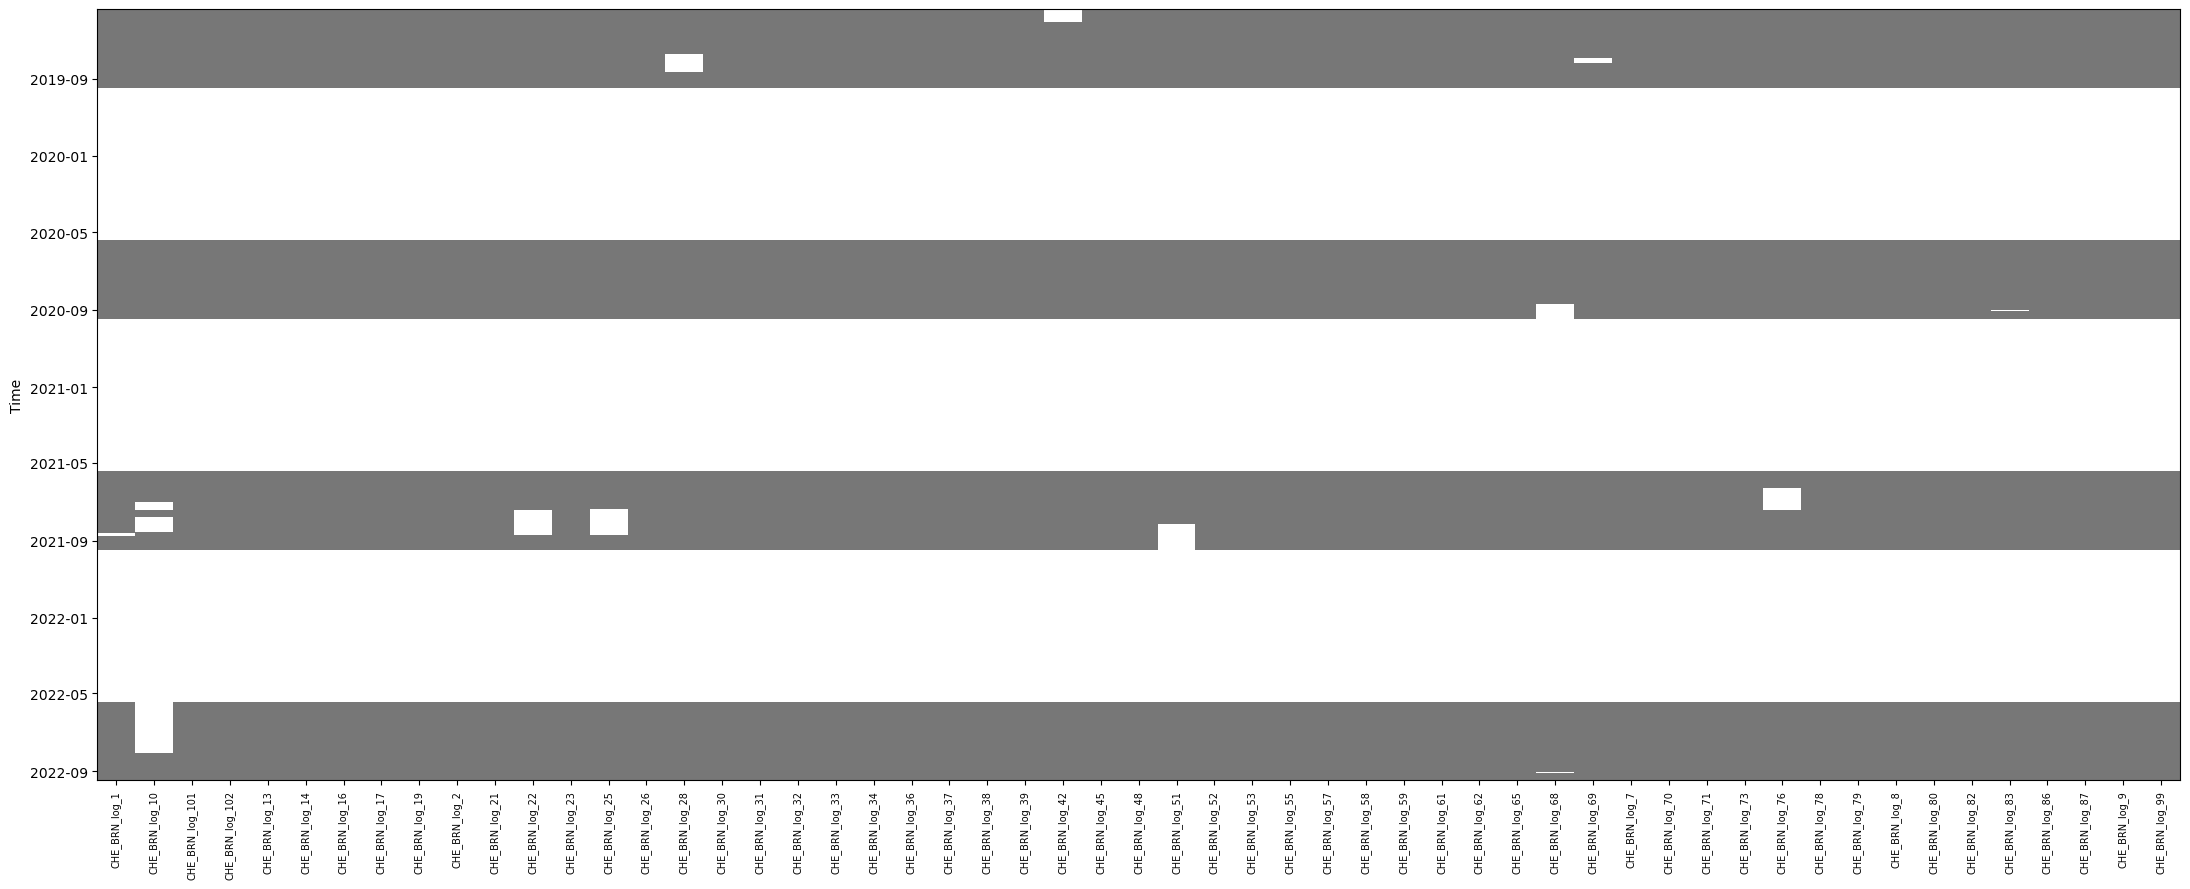

(<Figure size 2200x900 with 1 Axes>, <Axes: ylabel='Time'>)

In [35]:
def availability(data: pd.DataFrame, freq="D"):
    # sort stations by ID instead of date
    stations = sorted(data["station_id"].unique())

    # get the time axis on which observations are given
    t0 = data["datetime_utc"].min().floor(freq)
    t1 = data["datetime_utc"].max().floor(freq)

    #slots that are available to be plotted according to the desired frequency (daily by default)
    slots = pd.date_range(t0, t1, freq=freq, tz="UTC")

    fig, ax = plt.subplots(figsize=(max(8, 0.4 * len(stations)), 9))

    #we initialize an empty grid to fill the data availability with
    grid = np.full((len(slots), len(stations)), np.nan)
    # j = counter, sid = station id
    for j, sid in enumerate(stations):
        # which slots does this station have any obs in?
        s = data.loc[data["station_id"] == sid, "datetime_utc"]
        # bin this station's obs onto the SAME slots via floor, then mark hits
        binned = s.dt.floor(freq)
        
        # this will bin any number of hourly observations to the same day
        hit = pd.Series(True, index=binned).groupby(level=0).any()

        # we re-align this station's observational span to the span of the entire series and do not fill empty values
        hit = hit.reindex(slots, fill_value=False)

        # fill the grid with 1 when we have observations
        grid[hit.values, j] = 1.0 

    one_gray = ListedColormap([cmc.grayC(0.5)])    
    # use pcolormesh method for gridded data
    ax.pcolormesh(np.arange(len(stations)), slots, grid,
                  cmap=one_gray, vmin=0, vmax=1, shading="nearest")

    ax.set_xticks(np.arange(len(stations)))          # 0,1,2,... = cell centers
    ax.set_xticklabels(stations, rotation=90, fontsize=7)
    ax.set_ylabel("Time")
    ax.invert_yaxis()          # earliest at top, latest at bottom
    fig.tight_layout()
    plt.show()
    return fig, ax

availability(data)

# Raster data
Okay now that we have clean data and we know what it looks like, we can start processing the predictors we might need.

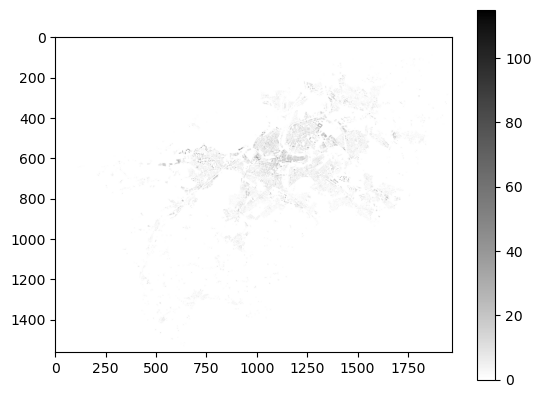

In [36]:
quick_raster_plot(city,"bh") #options are all 4 cities, buildings, tcd, lcz, terrain

We need to process all of this data to the same standard, and decide which resolution we want to work with. 

In [37]:
from rasterio.enums import Resampling
import rasterio
from rasterio.warp import reproject
import numpy as np




def coarsen_raster(src_path, dst_path, target_res):
    with rasterio.open(src_path) as src:
        # obtain the current pixel size, e.g. (10.0, 10.0)
        cur_x, cur_y = src.res            
        print(f"current pixel size is {cur_x}, {cur_y}")

        # we only want to coarsen the rasters bc they are already given at the finest resolution possible
        if target_res < max(cur_x, cur_y):
            raise ValueError(
                f"target {target_res} m is finer than source "
                f"{cur_x}x{cur_y} m — this only coarsens"
            )

        band = src.read(1)

        # we detect any noData values
        msk = src.read_masks(1)

        # and set them to 0
        band[msk == 0] = 0

        # calculate the scaling factor
        fx = cur_x / target_res
        fy = cur_y / target_res

        # the new raster will contain less pixels in each direction, scaled by the factor
        new_w = max(1, round(src.width * fx))
        new_h = max(1, round(src.height * fy))

        # we initialize the empty coarsened raster with these pixel counts
        dst_arr = np.empty((new_h, new_w), dtype="float32")

        # we ensure that the new raster conserves its georeferencing: we multiply the fine transform(fine pixels x CRS)
        # by the scaling factor to obtain the new transform(coarse pixels x CRS)
        transform = src.transform * src.transform.scale(src.width / new_w,
                                                        src.height / new_h)
        reproject(
            band, dst_arr,                                # we reproject from source to destination arrays
            src_transform=src.transform, src_crs=src.crs, # from the source transform and CRS
            dst_transform=transform, dst_crs=src.crs,     # to the coarsened geospatial transform, but same source CRS
            resampling=Resampling.average,                # with the average resampling method
        )

        # we copy the metadata from the source raster
        profile = src.profile.copy()

        # we update the metadata with the new amount of pixels and transform
        profile.update(height=new_h, width=new_w, transform=transform)

    # we write to the destination file to save the new raster
    with rasterio.open(dst_path, "w", **profile) as dst:
        dst.write(dst_arr, 1)


base_path = "../data/"
target_resolution = 50
coarsen_raster(base_path + "dtm/bern_30.tif", base_path + f"dtm/bern_{target_resolution}_coarsened.tif", target_resolution)

current pixel size is 30.0, 30.0


At this point, we need to decide which resolution we will be working with... If we want to work at the base resolution, the rasters can stay as is, otherwise we should coarsen them to the desired resolution and then proceed.

## Adding the raster data to our data frames
The shallow ML and statistical models we are reviewing require dataframes for training, as opposed to e.g. a convolutional neural network (CNN) which would require image data, in which case the rasters would be left as is. Instead, we need to assign to our point measurements a value issued from the rasters by obtaining the raster data from the nearest cell neighbour to the measurements.Luckily, rasterio has just the thing for us:

In [38]:
import numpy as np
import rasterio    
from pyproj import Transformer


# we prepare a helper function that can extract the geospatial data at different buffer radii
def sample_point_and_buffers(band, transform, res, x, y,
                             radii=(50, 100, 250, 500, 750, 1000)):
    """band: 2D array with nodata ALREADY filled to 0. Returns dict of predictors."""

    # transform.rowcol returns the raster cell that that x and y fall into
    row, col = rasterio.transform.rowcol(transform, x, y)
    out = {}

    # we check if the point measurement is actually contained in the extent of the raster
    if 0 <= row < band.shape[0] and 0 <= col < band.shape[1]:
        out["nearest"] = band[row, col]
    else:
        print("out of bounds")
        out["nearest"] = np.nan

    if not radii:                 # nearest-only: skip all the window/buffer work
        return out
        
    # next we extract data from the maximum buffer radius in our list
    # rmax returns the maximum amount of cells in the horizontal or vertical direction
    rmax = int(np.ceil(max(radii) / res))
    # we compute which row and column this radius would absorb
    # clipping it to 0 (minmum raster extent) on the low end and the maximum extent of the raster on the high end
    r0, r1 = max(0, row - rmax), min(band.shape[0], row + rmax + 1)
    c0, c1 = max(0, col - rmax), min(band.shape[1], col + rmax + 1)

    # we extract this large square once, which will contain all the data needed for the circular buffers
    window = band[r0:r1, c0:c1]

    # ogrid is an efficient way to build a grid
    # wr is a column vector holding row indices and wc a row vector containing column indices
    wr, wc = np.ogrid[r0:r1, c0:c1]

    # dist computes the distances from each pixel in the window to the center pixel (i.e. the station)
    # the value is in meters after being multiplied by res
    dist = np.sqrt((wr - row) ** 2 + (wc - col) ** 2) * res

    # we iterate over the radii 
    for radius in radii:
        # we slice the maximum window to cells that are within the radius (dist contains every pixel's distance to the station)
        # this effectively creates a pixelated circle around the station
        vals = window[dist <= radius]
        # we return a column to the dataframe named after the buffer radius containing the mean of the values within the buffer
        out[f"buf_{radius}"] = np.mean(vals) if vals.size else np.nan

    return out



def build_station_predictors(df, raster_paths, radii=(50, 100, 250, 500, 750, 1000)):
    # we want to isolate individual stations
    stn = (df.groupby("station_id")                 # groupby groups our dataframe by station id
             .agg(latitude=("latitude", "first"),   # .agg reduces dimensionality: here we take the first lat and lon 
                  longitude=("longitude", "first")) # because all datetime entries for a single station have the same lat and lon
             .reset_index())                        # we reset the index so that station_id becomes a data column and not an index column
                                                    
    # we prepare a CRS transformer to convert lat/lon to EPSG:3035 northing/easting
    to_3035 = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)
    stn["x"], stn["y"] = to_3035.transform(stn["longitude"].values,
                                           stn["latitude"].values)

    # We loop over each raster file first to open them only once
    for name, path in raster_paths.items():         # raster_paths is a dictionary containing a key (the name) and a value (the raster path)
        with rasterio.open(path) as src:
            band = src.read(1).astype("float32")
            msk = src.read_masks(1)                 
            band[msk == 0] = 0                      # we set noData values to 0 
            if name in ("tcd", "imp"):
                band[band == 255] = 0               # water tiles have a value of 255 in the Copernicus HRL                    
            transform, res = src.transform, src.res[0]

        # pandas iterrows iterates one row at a time, i.e. one station at a time
        for i, r in stn.iterrows():                 # i is the row index and r the row contents 

            # we now call our helper function, which takes the following arguments:
            s = sample_point_and_buffers(
                band,                               # band contains the data
                transform,                          # transform contains the pixel-geospatial transformation info,                        
                res,                                # which we need to go to/from pixel-geospatial coordinates referencing
                r["x"], r["y"],                     # this station's coordinates in the raster's CRS
                radii)                              # a range of distances in meters, optional as we have a hardcoded default 
            # s returns a dict of values (from nearest to buffer radius 1000)

            # assigns the raster value according to what pixel the station falls into, to a new column on our dataframe
            stn.loc[i, f"{name}_nearest"] = s["nearest"] 
            # we iteratively assign the buffer radius values to the dataframe with dynamic column naming
            for radius in radii:
                stn.loc[i, f"{name}_buf{radius}"] = s[f"buf_{radius}"] 

    return stn   # one row per station, with all geo predictor columns


# --- usage ---
raster_paths = {
    "bh":  f"../data/bh/{city}_10.tif",
    "tcd": f"../data/tcd/{city}_10.tif",
    "imp": f"../data/imp/{city}_10.tif",
}
station_predictors = build_station_predictors(data, raster_paths)

# merge on station_id copies all of the geospatial data from station_id to all instances of station_id in the original dataframe
data = data.merge(station_predictors.drop(columns=["latitude", "longitude", "x", "y"]),
              on="station_id", how="left")



        

In [39]:
single_paths = {
    "dtm":  f"../data/dtm/{city}_30.tif",
    "lcz": f"../data/lcz/{city}_100.tif",
}
single_predictors = build_station_predictors(data, single_paths, radii=())

data = data.merge(single_predictors.drop(columns=["latitude", "longitude", "x", "y"]),
              on="station_id", how="left")

In [40]:
def onehot_lcz(df, col="lcz_nearest", prefix="LCZ", n_classes=17):
    """Turn lcz_nearest (float class code) into LCZ_1..LCZ_17 one-hot columns."""
    lcz_type = df[col].round().astype("Int64")     # 5.0 -> 5, nullable int keeps NaN

    for k in range(1, n_classes + 1):
        df[f"{prefix}_{k}"] = (lcz_type == k).astype("int8")

    return df

data = onehot_lcz(data, col="lcz_nearest")

In [41]:
# pick one station's first row (any timestamp works — geo predictors are time-invariant)
stations = data["station_id"].unique()
sid = stations[5]        # change this index: 0, 1, 2, ... = different stations
row = data[data["station_id"] == sid].iloc[0]

# the columns we added (everything from the rasters)
geo_cols = [c for c in data.columns
            if c not in ("station_id",
                         "datetime_utc", "air_temperature")]

print(f"Station: {sid}")
print(f"Timestamp: {row['datetime_utc']}")
for c in geo_cols:
    print(f"  {c:20s} {row[c]}")

Station: CHE_BRN_log_16
Timestamp: 2019-05-14 22:00:00+00:00
  latitude             46.9473
  longitude            7.4385
  bh_nearest           0.0
  bh_buf50             7.95061731338501
  bh_buf100            11.28391170501709
  bh_buf250            9.994900703430176
  bh_buf500            7.936775207519531
  bh_buf750            6.338295936584473
  bh_buf1000           5.909284591674805
  tcd_nearest          0.0
  tcd_buf50            0.0
  tcd_buf100           0.0
  tcd_buf250           1.5696073770523071
  tcd_buf500           4.964818477630615
  tcd_buf750           7.383526802062988
  tcd_buf1000          7.301906585693359
  imp_nearest          100.0
  imp_buf50            98.96295928955078
  imp_buf100           96.7634048461914
  imp_buf250           92.38041687011719
  imp_buf500           78.40777587890625
  imp_buf750           67.42655181884766
  imp_buf1000          65.50157928466797
  dtm_nearest          547.4000244140625
  lcz_nearest          2.0
  LCZ_1           

For LCZs : one-hot-encode or leave out

for DTM: TPI is the only that would make sense

## Meteorological data from ERA5-Land

We need to process netcdf4 files with xarray:

In [42]:
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
from pathlib import Path
from pyproj import Transformer
from tqdm import tqdm

# our ERA5-Land data covers all of Europe and is stored daily, so we pass the days and location we need
def load_era5land(nc_dir, geopot_path, lat0, lon0, needed_dates):
    nc_dir = Path(nc_dir)
    vars_ = ["t2m", "d2m", "ssrd", "tp", "u10", "v10", "sp"]
    frames = []
    missing = []

    # we iterate over all daily files, with tqdm to give us progress information
    for d in tqdm(needed_dates, desc=f"ERA5-Land ({len(needed_dates)} days)"):
        f = nc_dir / f"ERA5Land_{d}.nc"       # d formatted yyyy-mm-dd
        if not f.exists():
            missing.append(f.name)
            continue
        with xr.open_dataset(f) as ds:
            # we select the daily point data, .squeeze() removes the geographical coordinates as dimensions
            # so we end up with a single time-series of data
            pt = ds[vars_].sel(latitude=lat0, longitude=lon0, method="nearest").squeeze()

            # we convert the Dataset to a pandas DataFrame, reset_index makes our single column a data column
            # and not an index column
            frames.append(pt.to_dataframe().reset_index())

    if missing:
        print(f"warning: {len(missing)} needed files absent, e.g. {missing[:3]}")
    if not frames:
        raise FileNotFoundError(f"no matching ERA5-Land files found in {nc_dir}")

    # we concatenate our daily dataframes into one, we renumber our index 0 to N
    met = pd.concat(frames, ignore_index=True)

    # we rename our time column to ensure our dataframes match up later
    met = met.rename(columns={"valid_time": "datetime_utc"})

    # we ensure our datetime is tz-aware
    met["datetime_utc"] = pd.to_datetime(met["datetime_utc"], utc=True)

    
    met = (met[["datetime_utc", *vars_]]
           .drop_duplicates("datetime_utc").sort_values("datetime_utc")
           .reset_index(drop=True))

    gz = xr.open_dataset(geopot_path).sel(latitude=lat0, longitude=lon0,
                                          method="nearest").squeeze()
    era5_elev = float(gz["z"].values) / 9.80665
    gz.close()
    return met, era5_elev

In [43]:
def deaccumulate(met, col):
    out = met.sort_values("datetime_utc").copy()    # make sure the date_time utc is sorted
    hourly = out[col].diff()                        # this is the difference between subsequent timesteps
    reset = out["datetime_utc"].dt.hour == 1        # first step of daily window, taken as-is
    hourly[reset] = out.loc[reset, col]             # reset the values at 01:00 UTC

    # detect gaps: time since previous row should be exactly 1 hour
    dt = out["datetime_utc"].diff()
    
    gap = dt > pd.Timedelta(hours=1)
    # at a gap (non-01:00), the diff is untrustworthy -> NaN it
    hourly[gap & ~reset] = np.nan

    hourly = hourly.clip(lower=0)                   # make sure all values are positive
    out[f"{col}_deac"] = hourly                     # create a new column with suffic _deac
    return out

In [44]:
from thermofeel import calculate_relative_humidity_percent

def transform_met(met):
    m = met.copy()
    m["rh"]  = calculate_relative_humidity_percent(m["t2m"], m["d2m"]) # rh calculation from ecmwf
    m["t2m"] = m["t2m"] - 273.15
    m["d2m"] = m["d2m"] - 273.15
    m["wspd"] = np.sqrt(m["u10"]**2 + m["v10"]**2)
    return m

In [45]:
# city center coords for ERA5-Land nearest-cell selection
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="get_cc_coords")

location = geolocator.geocode("dortmund, germany")

lat0, lon0 = location.latitude, location.longitude

print(lat0, lon0)



51.5142273 7.4652789


In [46]:
needed = data["datetime_utc"].dt.strftime("%Y-%m-%d").unique()   
met, era5_elev = load_era5land(f"../../raw_data/era5land/",
                               f"../../raw_data/era5land/geopotential.nc",
                               lat0, lon0, needed_dates=needed)




ERA5-Land (499 days):   0%|          | 2/499 [00:00<03:01,  2.74it/s]

ERA5-Land (499 days): 100%|██████████| 499/499 [02:39<00:00,  3.13it/s]


In [47]:
met = deaccumulate(met, "ssrd")                                                  # 3
met = deaccumulate(met, "tp")
met = transform_met(met)                                                         # 4



In [48]:
before = len(data)

# finally, we broadcast all hourly values to all stations since we give the same forcing for all stations
data = data.merge(met, on="datetime_utc", how="left")                           # 5
assert len(data) == before, "met merge changed row count — duplicate timestamps"

# elevation corrected t2m is station-dependent, so we add this predictor at the end
data["t2m_corr"] = data["t2m"] - 0.0065 * (data["dtm_nearest"] - era5_elev)    

In [49]:
cols = ["station_id", "datetime_utc",
        "t2m", "t2m_corr", "d2m", "rh",
        "tp", "tp_deac", "ssrd", "ssrd_deac"]

print(data[cols].head(20).to_string(index=False))

     station_id              datetime_utc       t2m  t2m_corr       d2m        rh           tp      tp_deac       ssrd  ssrd_deac
CHE_BRN_log_101 2019-05-14 22:00:00+00:00  6.790680  3.735956  1.197174 67.452034 8.583069e-07 0.000000e+00 20191264.0        0.0
CHE_BRN_log_101 2019-05-14 23:00:00+00:00  6.016266  2.961542  1.005035 70.175400 8.583069e-07 0.000000e+00 20191264.0        0.0
CHE_BRN_log_101 2019-05-15 00:00:00+00:00  5.378815  2.324090  0.895660 72.772774 8.583069e-07 0.000000e+00 20191264.0        0.0
CHE_BRN_log_101 2019-05-15 01:00:00+00:00  4.682526  1.627801  0.874176 76.277657 0.000000e+00 0.000000e+00        0.0        0.0
CHE_BRN_log_101 2019-05-15 02:00:00+00:00  3.848785  0.794061  0.624908 79.432297 0.000000e+00 0.000000e+00        0.0        0.0
CHE_BRN_log_101 2019-05-15 03:00:00+00:00  3.163727  0.109003  0.327301 81.593292 0.000000e+00 0.000000e+00        0.0        0.0
CHE_BRN_log_101 2019-05-15 04:00:00+00:00  2.662262 -0.392462  0.079498 83.042984 0.000000

In [50]:
data = data.dropna()


In [51]:
print(data.shape)

(643516, 57)


In [52]:
print(data[cols].describe().T[["min", "max", "mean"]])
print("\nd2m > t2m rows:", (data["d2m"] > data["t2m"]).sum())      # should be 0
print("negative tp_deac:", (data["tp_deac"] < 0).sum())            # should be 0
print("t2m == t2m_corr rows:", (data["t2m"] == data["t2m_corr"]).sum())  # should be ~0

                 min           max          mean
t2m         2.662262  3.703751e+01  1.807001e+01
t2m_corr   -0.696012  3.450863e+01  1.518539e+01
d2m        -1.986664  2.200626e+01  1.203723e+01
rh         22.980381  1.000032e+02  7.018441e+01
tp          0.000000  5.678023e-02  1.328998e-03
tp_deac     0.000000  7.840201e-03  1.106423e-04
ssrd        0.000000  2.923580e+07  9.587295e+06
ssrd_deac   0.000000  3.282126e+06  7.330956e+05

d2m > t2m rows: 160
negative tp_deac: 0
t2m == t2m_corr rows: 0


In [53]:
from pathlib import Path

out_dir = Path("../dataframes_for_training")
out_dir.mkdir(parents=True, exist_ok=True)      # create folder if it doesn't exist

out_path = out_dir / f"{city}_training.parquet"
data.to_parquet(out_path, index=False)
print(f"saved {len(data):,} rows x {data.shape[1]} cols -> {out_path}")

saved 643,516 rows x 57 cols -> ../dataframes_for_training/bern_training.parquet
